# Projection Analysis

Compares the model projections (SSP1–5, 2030/2050/2100) against the observed 2024 CISI baseline.

- Per-pixel error maps (projection vs 2024)
- How error grows from 2030 → 2050 → 2100
- Correlation between CISI level and error magnitude

## 1. Imports and setup

In [2]:
import os
import numpy as np
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, binned_statistic

CISI_PATH   = r"READY_data\labels\2024_CISI_010deg_nearest.tif"
PRED_DIR    = "predictions"
SHP_PATH    = r"ne_10m_admin_0_countries\ne_10m_admin_0_countries.shp"
SSPS        = ["SSP1", "SSP2", "SSP3", "SSP4", "SSP5"]
YEARS       = [2030, 2050, 2100]

with rasterio.open(CISI_PATH) as src:
    cisi_2024 = src.read(1).astype(np.float32)
    bounds    = src.bounds
    valid     = ~np.isnan(cisi_2024)

world = gpd.read_file(SHP_PATH)
ext   = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Load all predictions
preds = {}
for ssp in SSPS:
    preds[ssp] = {}
    for year in YEARS:
        path = os.path.join(PRED_DIR, f"cisi_pred_{ssp}_{year}.tif")
        with rasterio.open(path) as src:
            preds[ssp][year] = src.read(1).astype(np.float32)

print("Loaded 2024 CISI and all 15 projections.")
print(f"Valid pixels: {valid.sum():,}")

Loaded 2024 CISI and all 15 projections.
Valid pixels: 87,346


## 2. Side-by-side: 2024 CISI vs SSP1 2030 projection

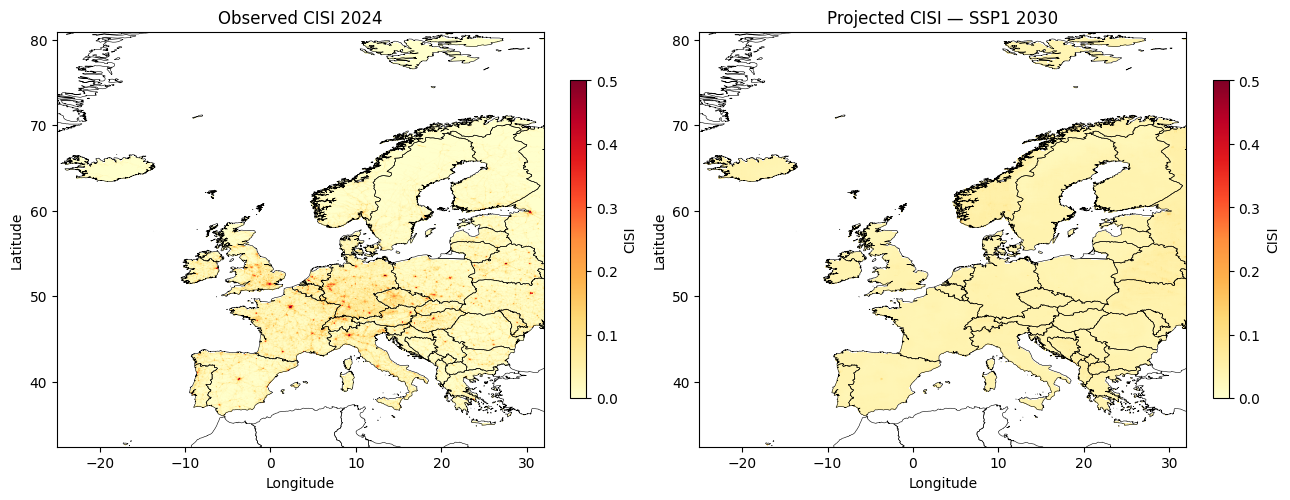

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(cisi_2024, cmap="YlOrRd", vmin=0, vmax=0.5,
                     extent=ext, origin="upper", aspect="auto")
world.boundary.plot(ax=axes[0], linewidth=0.4, color="black")
axes[0].set_xlim(bounds.left, bounds.right); axes[0].set_ylim(bounds.bottom, bounds.top)
axes[0].set_title("Observed CISI 2024")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
plt.colorbar(im0, ax=axes[0], label="CISI", fraction=0.03)

im1 = axes[1].imshow(preds["SSP1"][2030], cmap="YlOrRd", vmin=0, vmax=0.5,
                     extent=ext, origin="upper", aspect="auto")
world.boundary.plot(ax=axes[1], linewidth=0.4, color="black")
axes[1].set_xlim(bounds.left, bounds.right); axes[1].set_ylim(bounds.bottom, bounds.top)
axes[1].set_title("Projected CISI — SSP1 2030")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
plt.colorbar(im1, ax=axes[1], label="CISI", fraction=0.03)

plt.tight_layout()
plt.savefig("comparison_2024_vs_ssp1_2030.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Per-pixel error maps: projection minus 2024 (SSP1, all years)

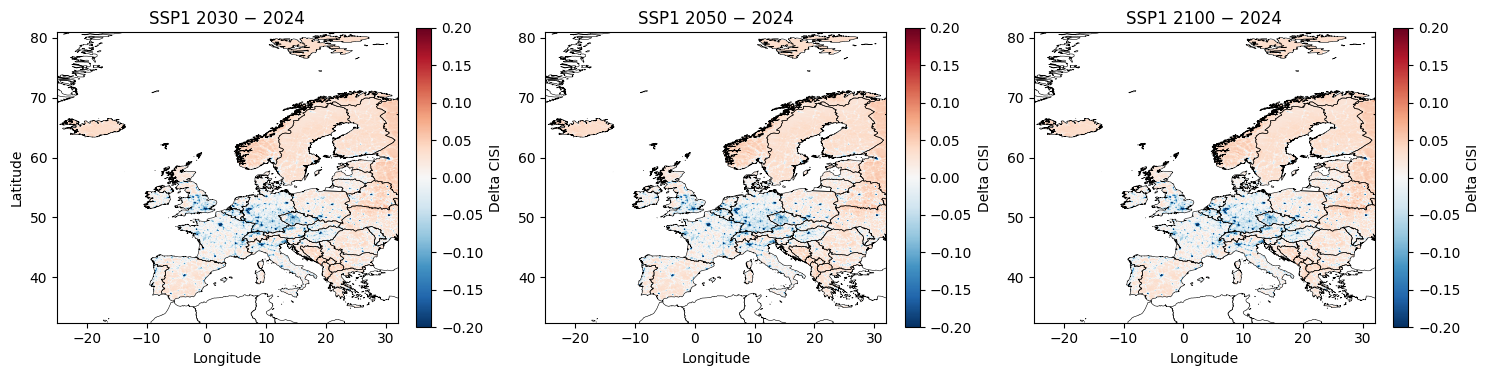

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, year in zip(axes, YEARS):
    error = preds["SSP1"][year] - cisi_2024
    im = ax.imshow(error, cmap="RdBu_r", vmin=-0.2, vmax=0.2,
                   extent=ext, origin="upper", aspect="auto")
    world.boundary.plot(ax=ax, linewidth=0.4, color="black")
    ax.set_xlim(bounds.left, bounds.right); ax.set_ylim(bounds.bottom, bounds.top)
    ax.set_title(f"SSP1 {year} − 2024")
    ax.set_xlabel("Longitude")
    plt.colorbar(im, ax=ax, label="Delta CISI", fraction=0.04)

axes[0].set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("error_maps_ssp1.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Mean absolute error per SSP per year vs 2024

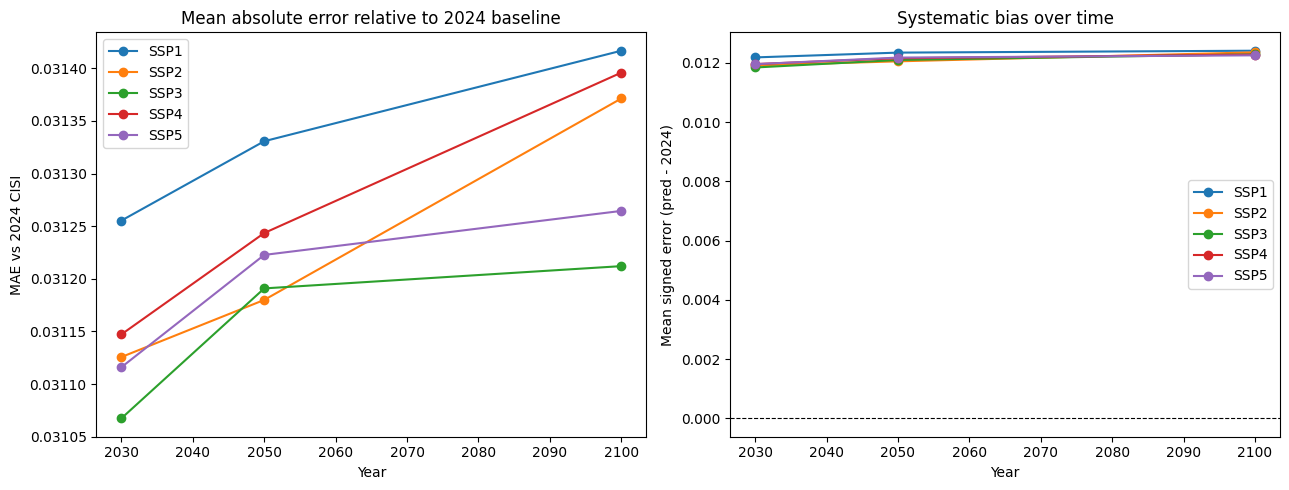

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: MAE per SSP per year
mae_table = {}
for ssp in SSPS:
    mae_table[ssp] = []
    for year in YEARS:
        err = np.abs(preds[ssp][year][valid] - cisi_2024[valid])
        mae_table[ssp].append(err.mean())

for ssp in SSPS:
    axes[0].plot(YEARS, mae_table[ssp], marker="o", label=ssp)
axes[0].set_xlabel("Year"); axes[0].set_ylabel("MAE vs 2024 CISI")
axes[0].set_title("Mean absolute error relative to 2024 baseline")
axes[0].legend()

# Right: mean signed error (bias)
for ssp in SSPS:
    bias = [np.mean(preds[ssp][year][valid] - cisi_2024[valid]) for year in YEARS]
    axes[1].plot(YEARS, bias, marker="o", label=ssp)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Mean signed error (pred - 2024)")
axes[1].set_title("Systematic bias over time")
axes[1].legend()

plt.tight_layout()
plt.savefig("error_over_time.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Correlation between 2024 CISI level and error magnitude

SSP      Year  Pearson r      p-value
------------------------------------
SSP1     2030    -0.9811     0.00e+00
SSP1     2050    -0.9816     0.00e+00
SSP1     2100    -0.9816     0.00e+00
SSP2     2030    -0.9811     0.00e+00
SSP2     2050    -0.9812     0.00e+00
SSP2     2100    -0.9816     0.00e+00
SSP3     2030    -0.9812     0.00e+00
SSP3     2050    -0.9821     0.00e+00
SSP3     2100    -0.9826     0.00e+00
SSP4     2030    -0.9813     0.00e+00
SSP4     2050    -0.9819     0.00e+00
SSP4     2100    -0.9821     0.00e+00
SSP5     2030    -0.9808     0.00e+00
SSP5     2050    -0.9812     0.00e+00
SSP5     2100    -0.9820     0.00e+00


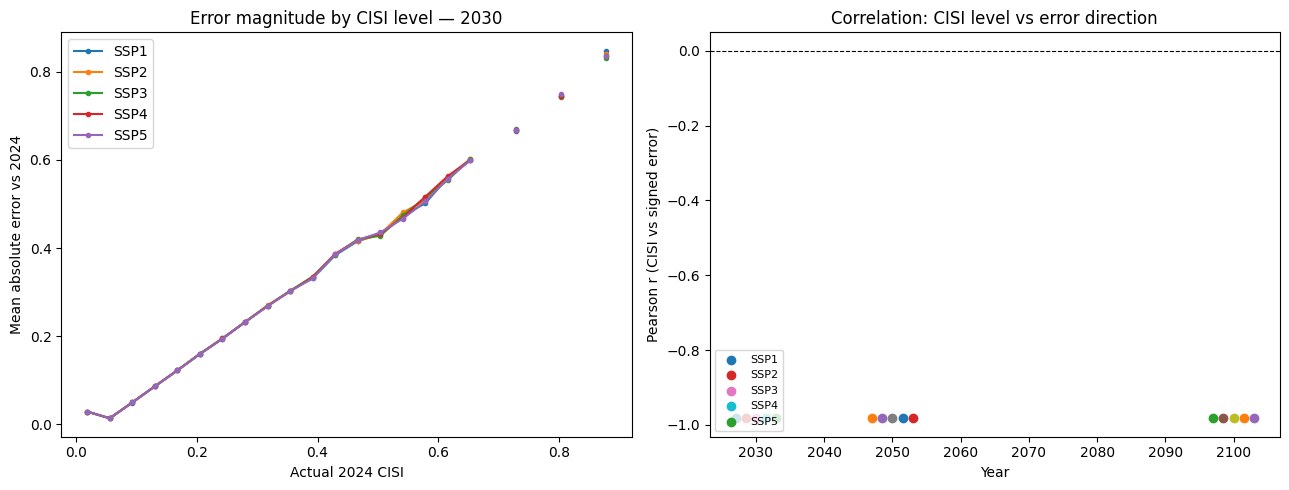

In [6]:
# Use SSP1 2030 as representative — repeat for other combos if needed
cisi_vals  = cisi_2024[valid]
bins       = np.linspace(0, np.nanmax(cisi_vals), 25)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ssp in SSPS:
    abs_err = np.abs(preds[ssp][2030][valid] - cisi_vals)
    mean_err, _, _ = binned_statistic(cisi_vals, abs_err, statistic="mean", bins=bins)
    axes[0].plot(bin_centers, mean_err, marker=".", label=ssp)

axes[0].set_xlabel("Actual 2024 CISI")
axes[0].set_ylabel("Mean absolute error vs 2024")
axes[0].set_title("Error magnitude by CISI level — 2030")
axes[0].legend()

# Pearson r for each SSP/year
print(f"{'SSP':<6} {'Year':>6} {'Pearson r':>10} {'p-value':>12}")
print("-" * 36)
for ssp in SSPS:
    for year in YEARS:
        signed_err = preds[ssp][year][valid] - cisi_vals
        r, p = pearsonr(cisi_vals, signed_err)
        axes[1].scatter(year + (SSPS.index(ssp) - 2) * 1.5, r, label=ssp if year == 2030 else "")
        print(f"{ssp:<6} {year:>6} {r:>10.4f} {p:>12.2e}")

axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Pearson r (CISI vs signed error)")
axes[1].set_title("Correlation: CISI level vs error direction")
axes[1].legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.savefig("cisi_vs_error_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Summary statistics table

In [7]:
print(f"{'SSP':<6} {'Year':>6} {'Mean pred':>10} {'Mean 2024':>10} {'MAE':>8} {'Bias':>8} {'High>0.15 (%)':>14}")
print("-" * 62)
cisi_mean = cisi_2024[valid].mean()
for ssp in SSPS:
    for year in YEARS:
        p = preds[ssp][year][valid]
        mae  = np.abs(p - cisi_2024[valid]).mean()
        bias = (p - cisi_2024[valid]).mean()
        high = (p > 0.15).mean() * 100
        print(f"{ssp:<6} {year:>6} {p.mean():>10.4f} {cisi_mean:>10.4f} {mae:>8.4f} {bias:>+8.4f} {high:>13.1f}%")


SSP      Year  Mean pred  Mean 2024      MAE     Bias  High>0.15 (%)
--------------------------------------------------------------
SSP1     2030     0.0406     0.0284   0.0313  +0.0122           0.0%
SSP1     2050     0.0408     0.0284   0.0313  +0.0123           0.0%
SSP1     2100     0.0408     0.0284   0.0314  +0.0124           0.0%
SSP2     2030     0.0403     0.0284   0.0311  +0.0119           0.0%
SSP2     2050     0.0405     0.0284   0.0312  +0.0121           0.0%
SSP2     2100     0.0408     0.0284   0.0314  +0.0124           0.0%
SSP3     2030     0.0403     0.0284   0.0311  +0.0118           0.0%
SSP3     2050     0.0405     0.0284   0.0312  +0.0121           0.0%
SSP3     2100     0.0407     0.0284   0.0312  +0.0123           0.0%
SSP4     2030     0.0404     0.0284   0.0311  +0.0120           0.0%
SSP4     2050     0.0406     0.0284   0.0312  +0.0122           0.0%
SSP4     2100     0.0407     0.0284   0.0314  +0.0123           0.0%
SSP5     2030     0.0404     0.0284   0.